In [ ]:
import sys
from pathlib import Path

PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")
SRC = str(PROJECT_PATH / "src")

if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(SRC)

/content/drive/MyDrive/UAH_Project/src


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

from tqdm.notebook import tqdm

In [ ]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

PROCESSED_DIR = (
    PROJECT_PATH /
    "datasets" /
    "optical_flow" /
    "processed"
)

print(PROCESSED_DIR.exists())

True


In [ ]:
metadata = pd.read_csv(
    PROCESSED_DIR / "metadata.csv"
)

metadata.head()

,file,label,label_name,group,windows
0,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,0,NORMAL,0,105
1,20151110180846-16km-D1-NORMAL2-SECONDARY_windo...,0,NORMAL,1,101
2,20151111123123-25km-D1-NORMAL-MOTORWAY_windows...,0,NORMAL,2,145
3,20151111125204-24km-D1-AGGRESSIVE-MOTORWAY_win...,2,AGGRESSIVE,3,129
4,20151111132343-25km-D1-DROWSY-MOTORWAY_windows...,1,DROWSY,4,158


In [ ]:
print(metadata.shape)

metadata

(40, 5)


,file,label,label_name,group,windows
0,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,0,NORMAL,0,105
1,20151110180846-16km-D1-NORMAL2-SECONDARY_windo...,0,NORMAL,1,101
2,20151111123123-25km-D1-NORMAL-MOTORWAY_windows...,0,NORMAL,2,145
3,20151111125204-24km-D1-AGGRESSIVE-MOTORWAY_win...,2,AGGRESSIVE,3,129
4,20151111132343-25km-D1-DROWSY-MOTORWAY_windows...,1,DROWSY,4,158
5,20151111134542-16km-D1-AGGRESSIVE-SECONDARY._w...,2,AGGRESSIVE,5,89
6,20151111135605-13km-D1-DROWSY-SECONDARY_window...,1,DROWSY,6,87
7,20151120131704-26km-D2-NORMAL-MOTORWAY_windows...,0,NORMAL,7,160
8,20151120133457-26km-D2-AGGRESSIVE-MOTORWAY_win...,2,AGGRESSIVE,8,146
9,20151120135150-25km-D2-DROWSY-MOTORWAY_windows...,1,DROWSY,9,158


In [ ]:
print(metadata.groupby("label_name")["windows"].sum())

print()

print(metadata.groupby("label_name").size())

label_name
AGGRESSIVE    1374
DROWSY        1667
NORMAL        2213
Name: windows, dtype: int64

label_name
AGGRESSIVE    11
DROWSY        12
NORMAL        17
dtype: int64


In [ ]:
samples = []

for _, row in metadata.iterrows():

    for window_idx in range(row["windows"]):

        samples.append({
            "file": row["file"],
            "window": window_idx,
            "label": row["label"],
            "group": row["group"]
        })

samples = pd.DataFrame(samples)

samples.head()

,file,window,label,group
0,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,0,0,0
1,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,1,0,0
2,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,2,0,0
3,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,3,0,0
4,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,4,0,0


In [ ]:
print(samples.shape)
samples

(5254, 4)


,file,window,label,group
0,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,0,0,0
1,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,1,0,0
2,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,2,0,0
3,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,3,0,0
4,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,4,0,0
...,...,...,...,...
5249,20151221120048-D6-AGGRESSIVE-MOTORWAY_windows.npy,149,2,39
5250,20151221120048-D6-AGGRESSIVE-MOTORWAY_windows.npy,150,2,39
5251,20151221120048-D6-AGGRESSIVE-MOTORWAY_windows.npy,151,2,39
5252,20151221120048-D6-AGGRESSIVE-MOTORWAY_windows.npy,152,2,39


In [ ]:
samples.groupby("label").size()

,0
label,
0,2213
1,1667
2,1374


In [ ]:
print(samples["group"].nunique())

40


In [ ]:
class OpticalFlowDataset(Dataset):

    def __init__(self, samples, processed_dir):
        self.samples = samples.reset_index(drop=True)
        self.processed_dir = Path(processed_dir)

        # Aynı dosyayı tekrar tekrar açmamak için cache
        self.cache = {}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        row = self.samples.iloc[idx]

        file_name = row["file"]
        window_idx = row["window"]
        label = row["label"]

        # Bellek eşlemeli (RAM dostu) yükleme
        if file_name not in self.cache:
            self.cache[file_name] = np.load(
                self.processed_dir / file_name,
                mmap_mode="r"
            )

        x = self.cache[file_name][window_idx]

        # (24,180,320,2) -> (24,2,180,320)
        x = np.transpose(x, (0, 3, 1, 2))

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.long)

        return x, y

In [ ]:
dataset = OpticalFlowDataset(
    samples,
    PROCESSED_DIR
)

print(len(dataset))

5254


In [ ]:
x, y = dataset[0]

print(x.shape)
print(y)

torch.Size([24, 2, 180, 320])
tensor(0)


In [ ]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

groups = samples["group"].values

logo_iterator = logo.split(
    samples,
    samples["label"],
    groups
)

In [ ]:
train_idx, test_idx = next(logo_iterator)

print(len(train_idx))
print(len(test_idx))

5149
105


In [ ]:
print("Train Groups :", samples.iloc[train_idx]["group"].nunique())
print("Test Groups  :", samples.iloc[test_idx]["group"].nunique())

print()

print("Test Group ID :", samples.iloc[test_idx]["group"].unique())

Train Groups : 39
Test Groups  : 1

Test Group ID : [0]


In [ ]:
train_samples = samples.iloc[train_idx]
test_samples = samples.iloc[test_idx]

train_dataset = OpticalFlowDataset(
    train_samples,
    PROCESSED_DIR
)

test_dataset = OpticalFlowDataset(
    test_samples,
    PROCESSED_DIR
)

print(len(train_dataset))
print(len(test_dataset))

5149
105


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_loader))
print(len(test_loader))

644
14


In [ ]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

torch.Size([8, 24, 2, 180, 320])
torch.Size([8])


In [ ]:
class FlowCNNEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(2,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)

        )

    def forward(self,x):

        x=self.features(x)

        x=x.view(x.size(0),-1)

        return x

In [ ]:
encoder = FlowCNNEncoder()

frame = x[:,0]

print(frame.shape)

feature = encoder(frame)

print(feature.shape)

torch.Size([8, 2, 180, 320])
torch.Size([8, 64])


In [ ]:
class CNNLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = FlowCNNEncoder()

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64,3)
        )

    def forward(self,x):

        B,T,C,H,W = x.shape

        # (B,T,C,H,W)
        # ->
        # (B*T,C,H,W)

        x = x.reshape(B*T,C,H,W)

        features = self.encoder(x)

        # (B*T,64)
        # ->
        # (B,T,64)

        features = features.reshape(B,T,-1)

        output,(hidden,cell) = self.lstm(features)

        logits = self.classifier(hidden[-1])

        return logits

In [ ]:
model = CNNLSTM()

logits = model(x)

print(logits.shape)

torch.Size([8, 3])


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
model = CNNLSTM().to(device)

print(model)

CNNLSTM(
  (encoder): FlowCNNEncoder(
    (features): Sequential(
      (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=1)
    )
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
classes = np.unique(train_samples["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_samples["label"]
)

weights = torch.FloatTensor(class_weights).to(device)

print(class_weights)

[0.81419987 1.02959408 1.2491509 ]


In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
EPOCHS = 20
PATIENCE = 3

best_accuracy = 0
counter = 0

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)

        correct += (pred == y).sum().item()

        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    correct = 0
    total = 0

    predictions = []
    labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)

            pred = logits.argmax(dim=1)

            predictions.extend(
                pred.cpu().numpy()
            )

            labels.extend(
                y.cpu().numpy()
            )

            correct += (pred == y).sum().item()

            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    epoch_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return (
        epoch_loss,
        epoch_acc,
        epoch_f1,
        labels,
        predictions
    )

In [ ]:
best_accuracy = 0

counter = 0

best_model = None

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        best_model = model.state_dict()

        counter = 0

    else:

        counter += 1

    if counter >= PATIENCE:

        print(f"\nEarly stopping at epoch {epoch+1}")

        break

Epoch 1/20 | Train Loss: 1.0981 | Train Acc: 0.3607 | Val Loss: 1.0336 | Val Acc: 0.9905
Epoch 2/20 | Train Loss: 1.0785 | Train Acc: 0.3919 | Val Loss: 1.0595 | Val Acc: 0.0000
Epoch 3/20 | Train Loss: 1.0649 | Train Acc: 0.4057 | Val Loss: 0.9875 | Val Acc: 0.1524
Epoch 4/20 | Train Loss: 1.0628 | Train Acc: 0.4127 | Val Loss: 1.0077 | Val Acc: 0.2095

Early stopping at epoch 4


In [ ]:
val_loss, val_acc, val_f1, labels, predictions = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(classification_report(
    labels,
    predictions,
    target_names=[
        "NORMAL",
        "DROWSY",
        "AGGRESSIVE"
    ],
    zero_division=0
))

              precision    recall  f1-score   support

      NORMAL       1.00      0.21      0.35       105
      DROWSY       0.00      0.00      0.00         0
  AGGRESSIVE       0.00      0.00      0.00         0

    accuracy                           0.21       105
   macro avg       0.33      0.07      0.12       105
weighted avg       1.00      0.21      0.35       105



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, predictions)

print(cm)

[[22 77  6]
 [ 0  0  0]
 [ 0  0  0]]


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
model = CNNLSTM().to(device)

print(model)

CNNLSTM(
  (encoder): FlowCNNEncoder(
    (features): Sequential(
      (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=1)
    )
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
classes = np.unique(train_samples["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_samples["label"]
)

weights = torch.FloatTensor(class_weights).to(device)

print(class_weights)

[0.81419987 1.02959408 1.2491509 ]


In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

In [ ]:
EPOCHS = 20
PATIENCE = 8

In [ ]:
best_accuracy = 0

counter = 0

best_model = None

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_acc > best_accuracy:

        best_accuracy = val_acc
        best_model = model.state_dict()
        counter = 0

    else:

        counter += 1

    if counter >= PATIENCE:

        print(f"\nEarly stopping at epoch {epoch+1}")
        break


model.load_state_dict(best_model)

print("\nBest Validation Accuracy:", best_accuracy)

Epoch 1/20 | Train Loss: 1.0985 | Train Acc: 0.3758 | Val Loss: 1.0668 | Val Acc: 0.3048 | Val F1: 0.1557
Epoch 2/20 | Train Loss: 1.0821 | Train Acc: 0.3842 | Val Loss: 1.0231 | Val Acc: 0.1714 | Val F1: 0.0976
Epoch 3/20 | Train Loss: 1.0695 | Train Acc: 0.3919 | Val Loss: 1.0735 | Val Acc: 0.1048 | Val F1: 0.0632
Epoch 4/20 | Train Loss: 1.0625 | Train Acc: 0.4166 | Val Loss: 1.1937 | Val Acc: 0.1333 | Val F1: 0.0784
Epoch 5/20 | Train Loss: 1.0589 | Train Acc: 0.4232 | Val Loss: 1.0368 | Val Acc: 0.2857 | Val F1: 0.1481
Epoch 6/20 | Train Loss: 1.0490 | Train Acc: 0.4341 | Val Loss: 1.2666 | Val Acc: 0.0952 | Val F1: 0.0580
Epoch 7/20 | Train Loss: 1.0313 | Train Acc: 0.4457 | Val Loss: 1.1424 | Val Acc: 0.3429 | Val F1: 0.1702
Epoch 8/20 | Train Loss: 1.0192 | Train Acc: 0.4700 | Val Loss: 1.4116 | Val Acc: 0.2476 | Val F1: 0.1323
Epoch 9/20 | Train Loss: 1.0125 | Train Acc: 0.5003 | Val Loss: 1.4247 | Val Acc: 0.1524 | Val F1: 0.1322
Epoch 10/20 | Train Loss: 0.9969 | Train Acc: 

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        labels,
        predictions,
        labels=[0,1,2],
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      NORMAL       1.00      0.74      0.85       105
      DROWSY       0.00      0.00      0.00         0
  AGGRESSIVE       0.00      0.00      0.00         0

    accuracy                           0.74       105
   macro avg       0.33      0.25      0.28       105
weighted avg       1.00      0.74      0.85       105



[[78 27]
 [ 0  0]]


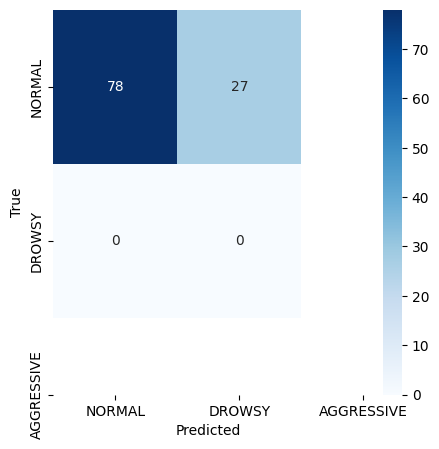

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    labels,
    predictions
)

print(cm)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "NORMAL",
        "DROWSY",
        "AGGRESSIVE"
    ],
    yticklabels=[
        "NORMAL",
        "DROWSY",
        "AGGRESSIVE"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
logo = LeaveOneGroupOut()

fold_accuracies = []
fold_f1_scores = []

all_labels = []
all_predictions = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(
    logo.split(
        samples,
        samples["label"],
        groups=samples["group"]
    )
):

    print("="*70)
    print(f"Fold {fold+1}/40")
    print("="*70)

Fold 1/40
Fold 2/40
Fold 3/40
Fold 4/40
Fold 5/40
Fold 6/40
Fold 7/40
Fold 8/40
Fold 9/40
Fold 10/40
Fold 11/40
Fold 12/40
Fold 13/40
Fold 14/40
Fold 15/40
Fold 16/40
Fold 17/40
Fold 18/40
Fold 19/40
Fold 20/40
Fold 21/40
Fold 22/40
Fold 23/40
Fold 24/40
Fold 25/40
Fold 26/40
Fold 27/40
Fold 28/40
Fold 29/40
Fold 30/40
Fold 31/40
Fold 32/40
Fold 33/40
Fold 34/40
Fold 35/40
Fold 36/40
Fold 37/40
Fold 38/40
Fold 39/40
Fold 40/40


In [ ]:
train_samples = samples.iloc[train_idx].reset_index(drop=True)
test_samples = samples.iloc[test_idx].reset_index(drop=True)

print(train_samples.shape)
print(test_samples.shape)

train_samples.head()

(5100, 4)
(154, 4)


,file,window,label,group
0,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,0,0,0
1,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,1,0,0
2,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,2,0,0
3,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,3,0,0
4,20151110175712-16km-D1-NORMAL1-SECONDARY_windo...,4,0,0


In [ ]:
train_dataset = OpticalFlowDataset(
    train_samples,
    PROCESSED_DIR
)

test_dataset = OpticalFlowDataset(
    test_samples,
    PROCESSED_DIR
)

print(len(train_dataset))
print(len(test_dataset))

5100
154


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_loader))
print(len(test_loader))

319
10


In [ ]:
EPOCHS = 10
PATIENCE = 3

In [ ]:
logo = LeaveOneGroupOut()

fold_accuracies = []
fold_f1_scores = []

all_labels = []
all_predictions = []

for fold, (train_idx, test_idx) in enumerate(

    logo.split(
        samples,
        samples["label"],
        groups=samples["group"]
    )

):

    print("=" * 70)
    print(f"Fold {fold+1}/40")
    print("=" * 70)

    # ============================================================
    # Dataset
    # ============================================================

    train_samples = samples.iloc[train_idx].reset_index(drop=True)
    test_samples = samples.iloc[test_idx].reset_index(drop=True)

    train_dataset = OpticalFlowDataset(
        train_samples,
        PROCESSED_DIR
    )

    test_dataset = OpticalFlowDataset(
        test_samples,
        PROCESSED_DIR
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(
        f"Train Windows : {len(train_dataset)} | "
        f"Test Windows : {len(test_dataset)}"
    )

    # ============================================================
    # Model
    # ============================================================

    model = CNNLSTM().to(device)

    classes = np.unique(train_samples["label"])

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_samples["label"]
    )

    weights = torch.FloatTensor(class_weights).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=weights
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=5e-4,
        weight_decay=1e-4
    )

    # ============================================================
    # Training
    # ============================================================

    best_accuracy = -1
    best_model = None
    counter = 0

    for epoch in range(EPOCHS):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            device
        )

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_accuracy:

            best_accuracy = val_acc
            best_model = model.state_dict()
            counter = 0

        else:

            counter += 1

        if counter >= PATIENCE:
            print("Early Stopping")
            break

    # ============================================================
    # Best Model Evaluation
    # ============================================================

    if best_model is not None:
        model.load_state_dict(best_model)

    val_loss, val_acc, val_f1, labels, predictions = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    fold_accuracies.append(val_acc)
    fold_f1_scores.append(val_f1)

    all_labels.extend(labels)
    all_predictions.extend(predictions)

    print(f"Best Accuracy : {val_acc:.4f}")
    print(f"Best F1       : {val_f1:.4f}")

Fold 1/40
Train Windows : 5149 | Test Windows : 105
Epoch 1/10 | Train Acc: 0.3440 | Val Acc: 0.0000
Epoch 2/10 | Train Acc: 0.3890 | Val Acc: 0.0286
Epoch 3/10 | Train Acc: 0.3859 | Val Acc: 0.0190
Epoch 4/10 | Train Acc: 0.3956 | Val Acc: 0.1619
Epoch 5/10 | Train Acc: 0.4022 | Val Acc: 0.0190
Epoch 6/10 | Train Acc: 0.4092 | Val Acc: 0.1429
Epoch 7/10 | Train Acc: 0.4152 | Val Acc: 0.1238
Early Stopping
Best Accuracy : 0.1238
Best F1       : 0.0734
Fold 2/40
Train Windows : 5153 | Test Windows : 101
Epoch 1/10 | Train Acc: 0.3270 | Val Acc: 0.0396
Epoch 2/10 | Train Acc: 0.3697 | Val Acc: 0.0000
Epoch 3/10 | Train Acc: 0.3782 | Val Acc: 0.0396
Epoch 4/10 | Train Acc: 0.3906 | Val Acc: 0.0198
Early Stopping
Best Accuracy : 0.0198
Best F1       : 0.0129
Fold 3/40
Train Windows : 5109 | Test Windows : 145
Epoch 1/10 | Train Acc: 0.3218 | Val Acc: 0.0000
Epoch 2/10 | Train Acc: 0.3500 | Val Acc: 0.0345
Epoch 3/10 | Train Acc: 0.3780 | Val Acc: 0.1103
Epoch 4/10 | Train Acc: 0.3735 | Val